In [2]:
import os

In [3]:
import joblib
import shap

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
os.chdir('C:/Users/basleal/Desktop/tutorial/kaim-week-8-9')

In [6]:
model_lg = joblib.load('models/linear_regression_model.pkl')
model_rf = joblib.load('models/random_forrest_model.pkl')
model_gb = joblib.load('models/gradient_boost_model.pkl')
model_cnn = joblib.load('models/cnn_model.pkl')
model_rnn = joblib.load('models/rnn_model.pkl')

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
import pandas as pd

In [8]:
path = 'data/fraud_data_final.csv'
path_2 = 'data/creditcard.csv'
fraud_data=pd.read_csv(path)
credit_data=pd.read_csv(path_2)
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

In [9]:
from sklearn.model_selection import train_test_split
x_fraud_data = fraud_data.drop(columns=['class','device_id','user_id','source', 'browser', 'sex','country','Unnamed: 0','Unnamed: 0.1','Unnamed: 0.2','signup_time','purchase_time'])
y_fraud_data = fraud_data['class']
x_train_fraud,x_test_fraud, y_train_fraud, y_test_fraud = train_test_split(x_fraud_data,y_fraud_data,test_size=0.2,random_state=42) 

In [10]:
x_train_fraud.columns

Index(['purchase_value', 'age', 'ip_address', 'time_diff_hours',
       'transaction_count', 'hour_of_day', 'day_of_week',
       'purchase_value_scaled', 'time_diff_hours_scaled', 'browser_encoded',
       'sex_encoded', 'age_encoded'],
      dtype='object')

In [11]:
smote=SMOTE()
x_train_balanced, y_train_balanced = smote.fit_resample(x_train_fraud, y_train_fraud)


In [12]:
explainer = shap.Explainer(model_lg,x_train_balanced)


Calculate the shap values

In [13]:
shap_values = explainer(x_test_fraud)

summary plot

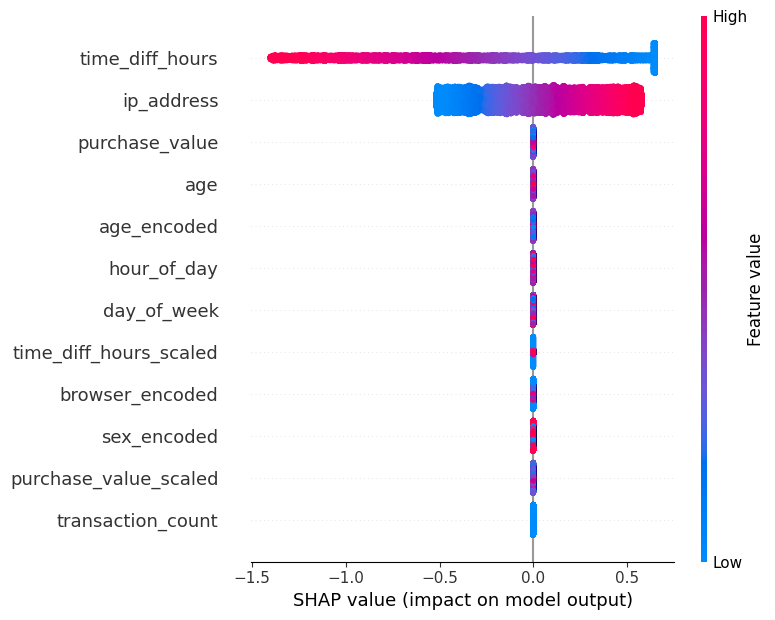

In [14]:
shap.summary_plot(shap_values, x_test_fraud)

Interpretations:
Feature Importance:

time_diff_hours and ip_address are the most important features affecting the model’s predictions.
purchase_value and age are also significant.
purchase_value_scaled and transaction_count are less significant

In [15]:
shap.initjs()

In [16]:
shap.force_plot(explainer.expected_value, shap_values[0].values, x_test_fraud.iloc[0])

Base Value:
The base value is -0.1054, which represents the model's average prediction before any features are considered.

Prediction Explanation:
The final predicted value (f(x)) is 0.17.
The red section represents features pushing the prediction upwards (toward higher values).
The blue section represents features pushing the prediction downwards (toward lower values).

Feature Impact:
ip_address:
Its value is 3.315e+9, and it pushes the prediction up significantly (shown in red).
time_diff_hours:
Its value is 951.5, and it pushes the prediction down (shown in blue).

In this case, the ip_address has a strong positive effect on the prediction, driving the predicted value higher, while time_diff_hours has a smaller negative effect. The overall result is a predicted value of 0.17 after considering both feature contributions.

next we will do dependency test

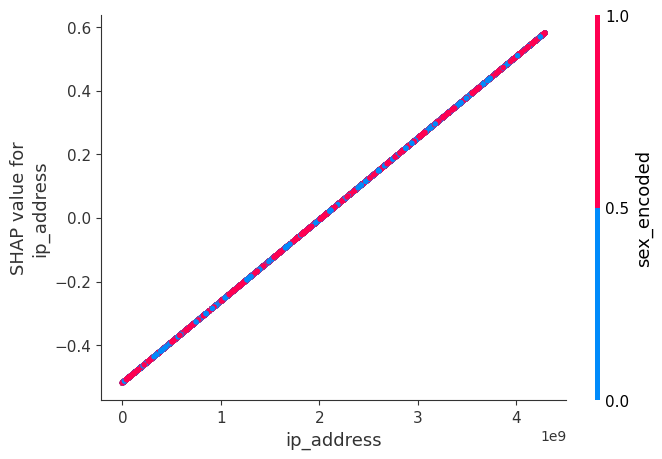

In [17]:
#shap.dependence_plot(['purchase_value', 'age', 'ip_address', 'time_diff_hours',
#       'transaction_count', 'hour_of_day', 'day_of_week',
#       'purchase_value_scaled', 'time_diff_hours_scaled', 'browser_encoded',
#       'sex_encoded', 'age_encoded'], shap_values, x_test_fraud)
import numpy as np
shap_values_array = np.array(shap_values.values)
shap.dependence_plot('ip_address', shap_values_array, x_test_fraud)

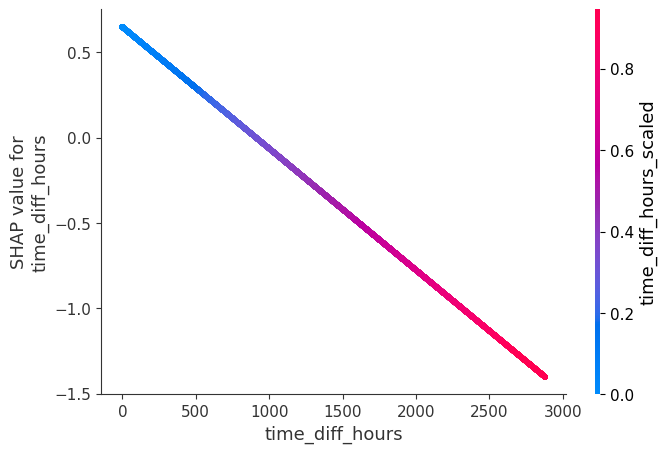

In [18]:
shap.dependence_plot('time_diff_hours', shap_values_array, x_test_fraud)

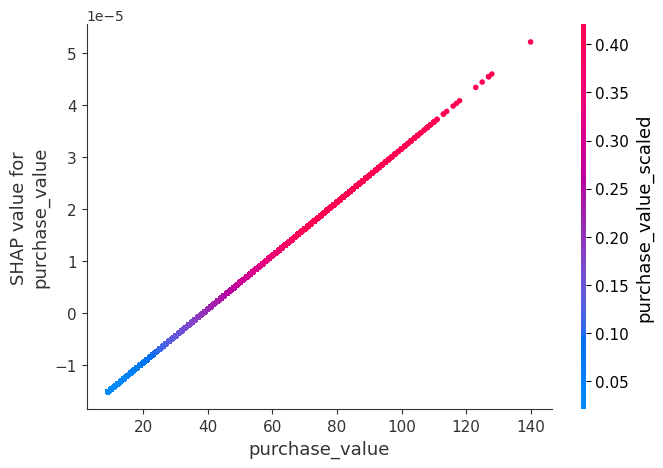

In [19]:
shap.dependence_plot('purchase_value', shap_values_array, x_test_fraud)